# 🧠 Modelo 3: Transfer Learning (VGG16) + Data Augmentation

Este notebook utiliza el modelo VGG16 preentrenado para clasificar las imágenes OCT. El modelo se carga desde `modelos/modelo_transfer.py`.

---

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_transfer as transfer_model

print("✅ Librerías importadas")

✅ Librerías importadas


In [3]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')[0]

In [5]:
# Descargar y preparar dataset en carpeta local (Disco D)
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (128, 128) 
BATCH_SIZE = 64

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb', # Cambiamos a RGB para VGG16
    train_subset_fraction=1,
    optimize=False
)

✅ Dataset en: /home/palodo2/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (128, 128)
   • Batch size: 64
   • Label mode: int
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      1196 batches
Validation: 342 batches
Test:       171 batches



In [6]:
# Crear y compilar el modelo
model = transfer_model.create_transfer_model(input_shape=(128, 128, 3), num_classes=4, use_augmentation=True)
model = transfer_model.compile_model(model, learning_rate=1e-5) # Reducimos para fine-tuning
transfer_model.print_model_summary(model)

Model: "TransferVGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 14,847,044 (56.64 MB)

 Non-trainable params: 0 (0.00 B)


📊 Parámetros totales: 14,847,044
📈 Parámetros entrenables: 14,847,044


In [7]:
# Entrenamiento (con fine-tuning y scheduler)
EPOCHS = 100
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/100


2026-03-14 13:37:43.073216: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1196/1196 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.8719 - loss: 0.3964 - val_accuracy: 0.9245 - val_loss: 0.2460 - learning_rate: 1.0000e-05
Epoch 2/100
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9373 - loss: 0.2046 - val_accuracy: 0.9389 - val_loss: 0.1987 - learning_rate: 1.0000e-05
Epoch 3/100
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9444 - loss: 0.1745 - val_accuracy: 0.9425 - val_loss: 0.1993 - learning_rate: 1.0000e-05
Epoch 4/100
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9496 - loss: 0.1593 - val_accuracy: 0.9476 - val_loss: 0.1667 - learning_rate: 1.0000e-05
Epoch 5/100
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9531 - loss: 0.1461 - val_accuracy: 0.9435 - val_loss: 0.1922 - learning_rate: 1.0000e-05
Epoch 6/100
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.9553 - loss: 0.1375 - val_accuracy: 0.9482 - val_loss: 0.1811 - learning_rate: 1.0000e-05
Epoch 7/100
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 

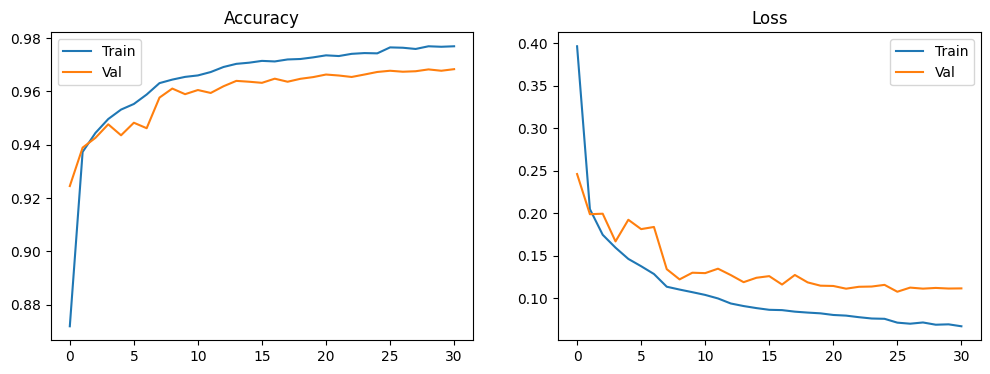

In [8]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

Loss en test: 0.1156
Accuracy en test: 0.9640

AUC por clase (One-vs-Rest):
 - CNV: 0.9983
 - DME: 0.9958
 - DRUSEN: 0.9839
 - NORMAL: 0.9973

AUC Promedio (Macro): 0.9938

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.97      0.97      0.97      3746
         DME       0.98      0.92      0.95      1161
      DRUSEN       0.84      0.83      0.84       887
      NORMAL       0.97      0.99      0.98      5139

    accuracy                           0.96     10933
   macro avg       0.94      0.93      0.94     10933
weighted avg       0.96      0.96      0.96     10933



2026-03-14 14:00:32.165187: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


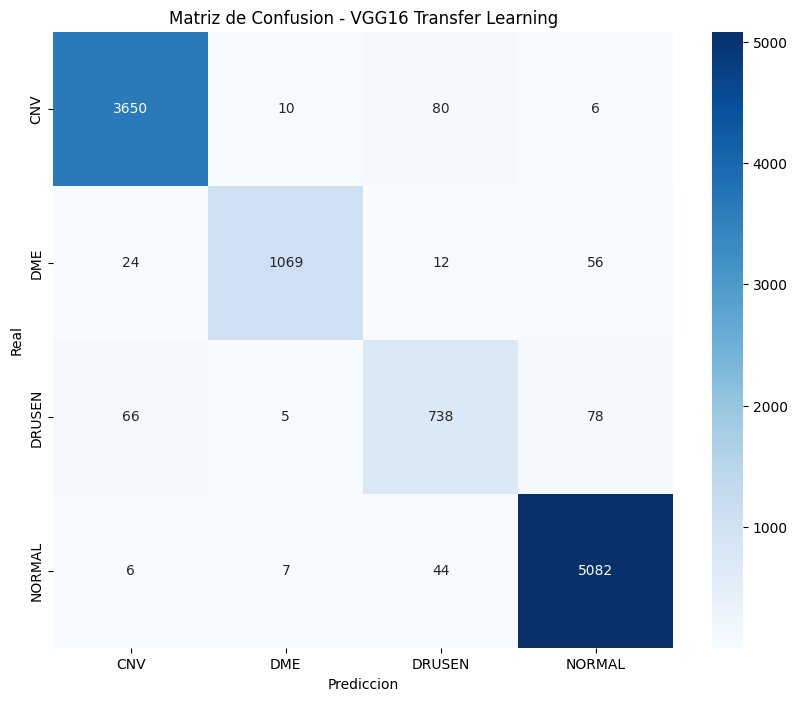

In [9]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred_labels = np.argmax(y_probs, axis=1)

# Verificar si y_true ya viene en formato One-Hot o como indices enteros
if len(y_true.shape) == 2 and y_true.shape[1] > 1:
    y_true_oh = y_true
    y_true_labels = np.argmax(y_true, axis=1)
else:
    y_true_labels = y_true
    y_true_oh = to_categorical(y_true, num_classes=len(class_names))

# Calculo de AUC por clase
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - VGG16 Transfer Learning')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()
